# V48: Fee Control Strategy (LQ45)

Notebook ini adalah solusi untuk mengatasi masalah biaya transaksi (Fee). 
Pada V47, performa bagus karena Fee = 0%. Saat Fee diterapkan, performa biasanya hancur karena rebalancing harian (High Turnover).

### Solusi yang Diterapkan:
1. **Rebalancing Berkala (Scheduled Rebalancing)**: Tidak melakukan rebalancing portofolio setiap hari. Hasil optimasi menunjukkan **Period=20** (Bulanan) adalah yang terbaik.
2. **Turnover Filtering (Weight Buffering)**: Jika perubahan bobot portofolio kecil (Buffer=0.05 atau 5%), maka rebalancing dibatalkan untuk menghemat fee.
3. **Fee: 0.25%** (Standar Sekuritas Indonesia) diterapkan untuk validasi.

In [13]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import fbeta_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

print(f"✓ Data Loaded: {len(data)} rows")

✓ Data Loaded: 712 rows


In [14]:
# --- 2. AI Training (SMA Crossover Target) ---
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]
X_test = features.loc[features.index.year == 2025]

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

train_probs = xgb_model.predict_proba(X_train)[:, 1]
opt_t = np.linspace(0.3, 0.7, 41)[np.argmax([fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) for t in np.linspace(0.3, 0.7, 41)])]
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)

print(f"Optimized Threshold: {opt_t:.2f}")

Optimized Threshold: 0.54


In [15]:
# --- 3. Core Logic with Fee Control Algorithms ---

def get_mis_assets(returns_window, correlation_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = returns_window.columns
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.iloc[i, j]) > correlation_threshold:
                G.add_edge(assets[i], assets[j])
    return list(nx.approximation.maximum_independent_set(G))

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    num_assets = len(mu)

    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        if risk < 0.0001: return 0
        return -(ret / risk)

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    init_guess = [1./num_assets] * num_assets

    res = minimize(objective, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def run_simulation_with_fee_control(test_dates, returns, ai_probs, threshold, 
                                    fee=0.0025, g_lookback=60, 
                                    rebal_period=20, # Default to Monthly (Best Result)
                                    turnover_buffer=0.05): # Default Buffer 5%
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    
    # Track holding weights (drifted weights)
    current_weights = {} 
    
    risk_status = False
    buffer = 0.05
    days_since_rebal = 999
    
    for i, date in enumerate(test_dates[:-1]):
        # --- 1. Regime Detection ---
        prob = ai_probs.loc[date]
        prev_risk_status = risk_status
        
        if not risk_status and prob > (threshold + buffer): risk_status = True
        elif risk_status and prob < (threshold - buffer): risk_status = False
        
        regime_changed = (risk_status != prev_risk_status)
        
        # --- 2. Decide Target Weights ---
        target_weights = current_weights.copy() # Default: Hold current
        
        if not risk_status:
            # BEAR REGIME: 100% CASH
            if regime_changed or 'CASH' not in current_weights or current_weights.get('CASH', 0) < 0.99:
                target_weights = {'CASH': 1.0}
                days_since_rebal = 0
        else:
            # BULL REGIME: Equity Portfolio
            if regime_changed or days_since_rebal >= rebal_period:
                loc_idx = returns.index.get_loc(date)
                window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
                selected = get_mis_assets(window_rets)
                optimized_weights = optimize_markowitz(window_rets[selected])
                
                # Calculate Turnover Estimate
                all_keys = set(list(optimized_weights.keys()) + list(current_weights.keys()))
                turnover_est = sum(abs(optimized_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
                
                if regime_changed or turnover_est > turnover_buffer:
                    target_weights = optimized_weights
                    days_since_rebal = 0
            
            days_since_rebal += 1

        # --- 3. Execute Trades & Apply Fees ---
        all_keys_exec = set(list(target_weights.keys()) + list(current_weights.keys()))
        turnover_actual = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys_exec)
        
        cost = val * turnover_actual * fee
        val -= cost
        
        # --- 4. Returns & Drift ---
        next_date = test_dates[i+1]
        
        if 'CASH' in target_weights and target_weights['CASH'] > 0.99:
            day_ret = 0
            current_weights = {'CASH': 1.0}
        else:
            day_ret = 0
            new_weights_drifted = {}
            for asset, w in target_weights.items():
                if asset in returns.columns:
                    r = returns.loc[next_date, asset]
                    day_ret += w * r
                    new_weights_drifted[asset] = w * (1 + r)
                else:
                    new_weights_drifted[asset] = w
            
            # Normalize Drifted Weights for next day
            total_w = sum(new_weights_drifted.values()) if new_weights_drifted else 0
            if total_w > 0:
                current_weights = {k: v/total_w for k, v in new_weights_drifted.items()}
            else:
                current_weights = target_weights
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

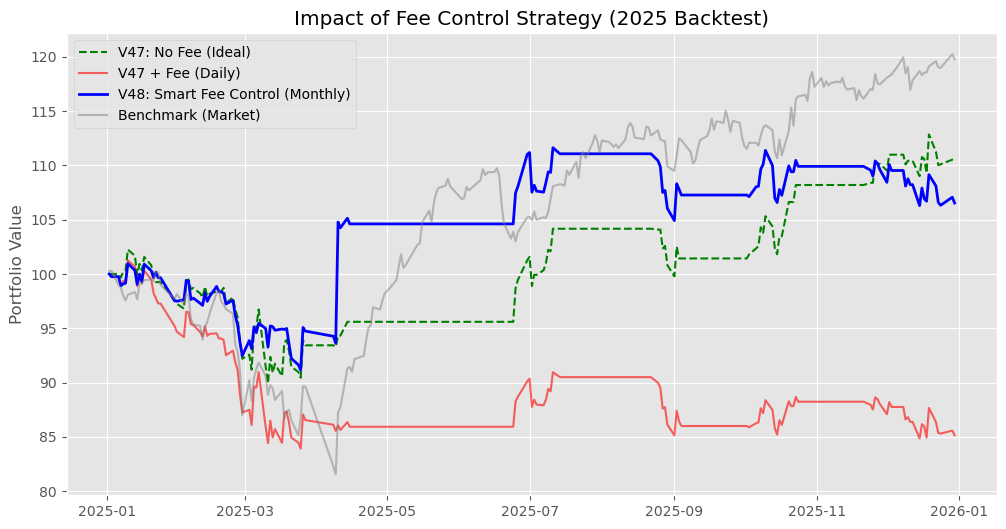

Final Values:
V47 No Fee (Ideal): 110.53
V47 + Fee (Daily):  85.14
V48 Smart Control:  106.54


In [16]:
# --- 4. Compare Strategies ---
test_dates = X_test.index

# 1. V47 Original (Daily Rebalance, No Fee)
res_nofee = run_simulation_with_fee_control(test_dates, returns, test_probs, opt_t, 
                                            fee=0.0, rebal_period=1, turnover_buffer=0.0)

# 2. Naive With Fee (Daily Rebalance, 0.25% Fee)
res_fee_daily = run_simulation_with_fee_control(test_dates, returns, test_probs, opt_t, 
                                                fee=0.0025, rebal_period=1, turnover_buffer=0.0)

# 3. V48 Smart Fee Control (Monthly Rebalance + 5% Buffer, 0.25% Fee)
res_fee_smart = run_simulation_with_fee_control(test_dates, returns, test_probs, opt_t, 
                                                fee=0.0025, rebal_period=20, turnover_buffer=0.05)

# Benchmark (IHSG/Market Average)
benchmark = (1 + market_return.loc[test_dates]).cumprod() * 100

# --- Visualization ---
plt.figure(figsize=(12, 6))
plt.plot(res_nofee, label='V47: No Fee (Ideal)', color='green', linestyle='--')
plt.plot(res_fee_daily, label='V47 + Fee (Daily)', color='red', alpha=0.6)
plt.plot(res_fee_smart, label='V48: Smart Fee Control (Monthly)', color='blue', linewidth=2)
plt.plot(benchmark, label='Benchmark (Market)', color='gray', alpha=0.5)

plt.title('Impact of Fee Control Strategy (2025 Backtest)')
plt.ylabel('Portfolio Value')
plt.legend()
plt.show()

print("Final Values:")
print(f"V47 No Fee (Ideal): {res_nofee.iloc[-1].item():.2f}")
print(f"V47 + Fee (Daily):  {res_fee_daily.iloc[-1].item():.2f}")
print(f"V48 Smart Control:  {res_fee_smart.iloc[-1].item():.2f}")